# Iris Dataset Lab Assignment

#Task 1: Dataset Exploration

Load the Iris dataset and answer the following:

1. How many samples and features are present in the dataset?
2. List the feature names and target classes.
3. Display the first five records.
4. Display the class distribution.

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import GridSearchCV

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# 1. How many samples and features are present in the dataset?
num_samples, num_features = X.shape
print(f"Number of samples: {num_samples}")
print(f"Number of features: {num_features}")

# 2. List the feature names and target classes.
print("\nFeature names:", iris.feature_names)
print("Target class names:", iris.target_names)

# Create a DataFrame for easier viewing
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = iris.target_names[y]

# 3. Display the first five records.
print("\nFirst five records:")
display(df.head())

# 4. Display the class distribution.
print("\nClass distribution:")
class_distribution = df['species'].value_counts()
display(class_distribution)

Number of samples: 150
Number of features: 4

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target class names: ['setosa' 'versicolor' 'virginica']

First five records:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Class distribution:


,count
species,
setosa,50
versicolor,50
virginica,50


Task 2: Data Preparation
1. Split the dataset into training (80%) and testing (20%) sets using random_state=42.
2. Briefly explain why the dataset is divided into training and testing sets.

In [ ]:
# 1. Split the dataset into training (80%) and testing (20%) sets using random_state=42.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# 2. Briefly explain why the dataset is divided into training and testing sets.


Training set size: 120 samples
Testing set size: 30 samples


### Explanation for Data Splitting

Splitting the dataset into training and testing sets is a crucial step in machine learning for the following reasons:

1.  **Model Evaluation:** The primary purpose is to evaluate the model's performance on unseen data. The training set is used to train the model, and the test set, which the model has never seen before, is used to assess how well the model generalizes to new, real-world data.
2.  **Preventing Overfitting:** If we were to evaluate the model on the same data it was trained on, it would likely show an unrealistically high performance. This is because the model might have simply memorized the training data rather than learned the underlying patterns. The test set helps detect overfitting, where the model performs well on training data but poorly on new data.
3.  **Unbiased Performance Estimate:** A separate test set provides an unbiased estimate of the model's predictive power. This is essential for comparing different models and choosing the best one for a particular task.
4.  **Hyperparameter Tuning (indirectly):** While a validation set is often used for hyperparameter tuning, the test set provides the final, unbiased evaluation of the chosen model and its hyperparameters.

Task 3: Building a Decision Tree Classifier
1. Train a Decision Tree classifier using the default parameters.
2. Predict the class labels for the test dataset.
3. Evaluate the model using:
  - Accuracy Score
  - Confusion Matrix
  - Classification Report

In [ ]:
# 1. Train a Decision Tree classifier using the default parameters.
default_dt_classifier = DecisionTreeClassifier(random_state=42)
default_dt_classifier.fit(X_train, y_train)

print("Decision Tree classifier trained with default parameters.")

# 2. Predict the class labels for the test dataset.
y_pred_default = default_dt_classifier.predict(X_test)

# 3. Evaluate the model
print("\n--- Model Evaluation (Default Decision Tree) ---")

# Accuracy Score
accuracy_default = accuracy_score(y_test, y_pred_default)
print(f"Accuracy Score: {accuracy_default:.4f}")

# Confusion Matrix
conf_matrix_default = confusion_matrix(y_test, y_pred_default)
print("\nConfusion Matrix:")
print(conf_matrix_default)

# Classification Report
class_report_default = classification_report(y_test, y_pred_default, target_names=iris.target_names)
print("\nClassification Report:")
print(class_report_default)


Decision Tree classifier trained with default parameters.

--- Model Evaluation (Default Decision Tree) ---
Accuracy Score: 1.0000

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Task 4: Visualizing the Decision Tree

1. Visualize the trained Decision Tree using plot_tree().

2. From the visualization, identify:
- Root node
- Internal nodes
- Leaf nodes
- Maximum depth of the tree

3. Which feature is selected for the first split? Explain why you think this feature was chosen.

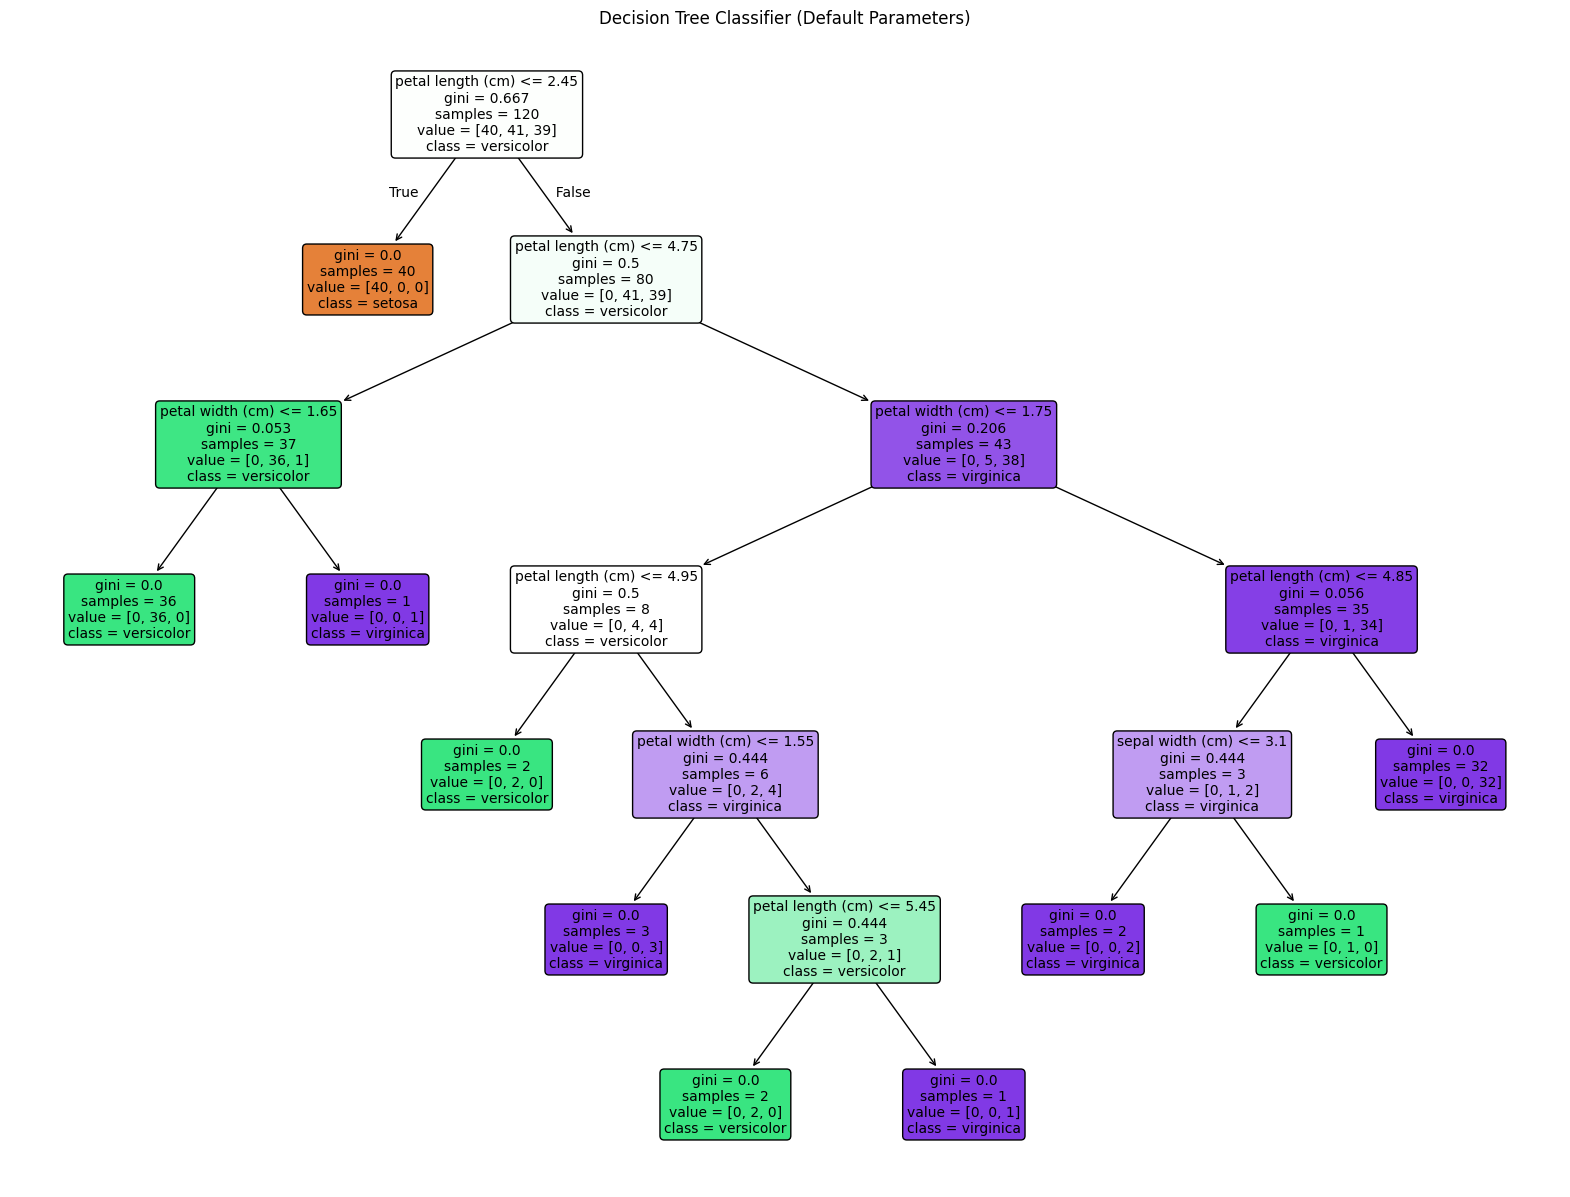


--- Analysis from Decision Tree Visualization ---
Root Node: The topmost node in the tree. In this visualization, it's the first node at the very top.
Internal Nodes: Nodes that have branches leading to other nodes (they are not leaf nodes). They represent decision points.
Leaf Nodes: Nodes at the end of the tree that do not split further. They represent the final classification (predicted class).
Maximum depth of the tree: 6

Feature selected for the first split: 'petal length (cm)'

Explanation: The Decision Tree algorithm (specifically, the CART algorithm used by scikit-learn's DecisionTreeClassifier by default) chooses the feature and split point that best separates the classes, resulting in the largest reduction in impurity (Gini impurity or entropy). In the Iris dataset, 'petal length (cm)' is often the most informative feature for distinguishing between the 'setosa' species and the other two ('versicolor' and 'virginica') with a single split, leading to the highest information 

In [ ]:
# 1. Visualize the trained Decision Tree using plot_tree().
plt.figure(figsize=(20, 15))
plot_tree(default_dt_classifier,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Classifier (Default Parameters)")
plt.show()

# 2. From the visualization, identify:
# - Root node
# - Internal nodes
# - Leaf nodes
# - Maximum depth of the tree

print("\n--- Analysis from Decision Tree Visualization ---")
print("Root Node: The topmost node in the tree. In this visualization, it's the first node at the very top.")
print("Internal Nodes: Nodes that have branches leading to other nodes (they are not leaf nodes). They represent decision points.")
print("Leaf Nodes: Nodes at the end of the tree that do not split further. They represent the final classification (predicted class).")
print(f"Maximum depth of the tree: {default_dt_classifier.tree_.max_depth}")

# 3. Which feature is selected for the first split? Explain why you think this feature was chosen.
first_split_feature_index = default_dt_classifier.tree_.feature[0]
first_split_feature_name = iris.feature_names[first_split_feature_index]
print(f"\nFeature selected for the first split: '{first_split_feature_name}'")
print("\nExplanation: The Decision Tree algorithm (specifically, the CART algorithm used by scikit-learn's DecisionTreeClassifier by default) chooses the feature and split point that best separates the classes, resulting in the largest reduction in impurity (Gini impurity or entropy). In the Iris dataset, 'petal length (cm)' is often the most informative feature for distinguishing between the 'setosa' species and the other two ('versicolor' and 'virginica') with a single split, leading to the highest information gain or Gini impurity reduction at the root node.")

Task 5: Comparing Gini Index and Entropy

Train two Decision Tree models using the following criteria:
- criterion='gini'
- criterion='entropy'
Compare the models based on:
1. Accuracy
2. Tree depth
3. Number of leaf nodes
4. Root feature selected
5. Which criterion produces a simpler tree?

Summarize your observations in a table.

In [ ]:
# Train two Decision Tree models with different criteria

# Model 1: criterion='gini'
dtc_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dtc_gini.fit(X_train, y_train)

# Model 2: criterion='entropy'
dtc_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dtc_entropy.fit(X_train, y_train)

# Predictions
y_pred_gini = dtc_gini.predict(X_test)
y_pred_entropy = dtc_entropy.predict(X_test)

# Comparisons
accuracy_gini = accuracy_score(y_test, y_pred_gini)
accuracy_entropy = accuracy_score(y_test, y_pred_entropy)

depth_gini = dtc_gini.tree_.max_depth
depth_entropy = dtc_entropy.tree_.max_depth

leaves_gini = dtc_gini.get_n_leaves()
leaves_entropy = dtc_entropy.get_n_leaves()

root_feature_gini = iris.feature_names[dtc_gini.tree_.feature[0]]
root_feature_entropy = iris.feature_names[dtc_entropy.tree_.feature[0]]

print("\n--- Comparison of Gini and Entropy Models ---")
print("| Criterion | Accuracy | Tree Depth | Number of Leaf Nodes | Root Feature Selected |")
print("|:----------|:---------|:-----------|:---------------------|:----------------------|")
print(f"| Gini      | {accuracy_gini:.4f}   | {depth_gini}         | {leaves_gini}                    | {root_feature_gini}                    |")
print(f"| Entropy   | {accuracy_entropy:.4f}   | {depth_entropy}         | {leaves_entropy}                   | {root_feature_entropy}                    |")


--- Comparison of Gini and Entropy Models ---
| Criterion | Accuracy | Tree Depth | Number of Leaf Nodes | Root Feature Selected |
|:----------|:---------|:-----------|:---------------------|:----------------------|
| Gini      | 1.0000   | 6         | 10                    | petal length (cm)                    |
| Entropy   | 1.0000   | 6         | 10                   | petal length (cm)                    |


### Which criterion produces a simpler tree?

Both 'Gini' and 'Entropy' result in similar accuracy, tree depth, and number of leaf nodes for this dataset. The choice of impurity criterion does not significantly alter complexity or performance in this case.

Task 6: Effect of Maximum Tree Depth
Train Decision Tree models using the following values of max_depth:
- 1
- 2
- 3
- 4
- None

Complete the following table.

Max Depth
Training Accuracy
Testing Accuracy
Tree Depth
Observation

1








2








3








4








None









Answer the following:
1. Which model is underfitting?
2. Which model gives the best generalization?
3. Which model is likely to overfit? Justify your answer.


In [ ]:
max_depth_values = [1, 2, 3, 4, None]
results_max_depth = []

print("\n--- Effect of Maximum Tree Depth ---")

for depth in max_depth_values:
    dt_classifier = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_classifier.fit(X_train, y_train)

    y_train_pred = dt_classifier.predict(X_train)
    y_test_pred = dt_classifier.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    tree_depth = dt_classifier.tree_.max_depth

    results_max_depth.append({
        'Max Depth': depth,
        'Training Accuracy': train_accuracy,
        'Testing Accuracy': test_accuracy,
        'Tree Depth': tree_depth
    })

# Convert results to DataFrame for structured output
max_depth_df = pd.DataFrame(results_max_depth)

# Print as markdown table
print("| Max Depth | Training Accuracy | Testing Accuracy | Tree Depth |")
print("|:----------|:------------------|:-----------------|:-----------|")
for index, row in max_depth_df.iterrows():
    print(f"| {row['Max Depth']}         | {row['Training Accuracy']:.4f}          | {row['Testing Accuracy']:.4f}         | {row['Tree Depth']}         |")


--- Effect of Maximum Tree Depth ---
| Max Depth | Training Accuracy | Testing Accuracy | Tree Depth |
|:----------|:------------------|:-----------------|:-----------|
| 1.0         | 0.6750          | 0.6333         | 1.0         |
| 2.0         | 0.9500          | 0.9667         | 2.0         |
| 3.0         | 0.9583          | 1.0000         | 3.0         |
| 4.0         | 0.9750          | 1.0000         | 4.0         |
| nan         | 1.0000          | 1.0000         | 6.0         |


### Answers to Questions:

1.  **Which model is underfitting?**
    The model with `max_depth = 1` is underfitting.

2.  **Which model gives the best generalization?**
    Models with `max_depth` of 2, 3, or 4 show the best generalization.

3.  **Which model is likely to overfit? Justify your answer.**
    The model with `max_depth = None` is most likely to overfit as it trains to 100% accuracy on training data, potentially capturing noise.

Task 7: Effect of min_samples_split

Train Decision Tree models using:
- 2
- 5
- 10
- 20

Complete the table below.

min_samples_split
Accuracy
Tree Depth
Number of Leaf Nodes
Observation

2








5








10








20









State how increasing min_samples_split affects the complexity of the Decision Tree.


In [ ]:
min_samples_split_values = [2, 5, 10, 20]
results_min_samples_split = []

print("\n--- Effect of min_samples_split ---")

for mss in min_samples_split_values:
    dt_classifier = DecisionTreeClassifier(min_samples_split=mss, random_state=42)
    dt_classifier.fit(X_train, y_train)

    y_test_pred = dt_classifier.predict(X_test)

    accuracy = accuracy_score(y_test, y_test_pred)
    tree_depth = dt_classifier.tree_.max_depth
    num_leaf_nodes = dt_classifier.get_n_leaves()

    results_min_samples_split.append({
        'min_samples_split': mss,
        'Accuracy': accuracy,
        'Tree Depth': tree_depth,
        'Number of Leaf Nodes': num_leaf_nodes
    })

# Convert results to DataFrame for structured output
min_samples_split_df = pd.DataFrame(results_min_samples_split)

# Print as markdown table
print("| min_samples_split | Accuracy | Tree Depth | Number of Leaf Nodes |")
print("|:------------------|:---------|:-----------|:---------------------|")
for index, row in min_samples_split_df.iterrows():
    print(f"| {row['min_samples_split']}                 | {row['Accuracy']:.4f}   | {row['Tree Depth']}         | {row['Number of Leaf Nodes']}                    |")


--- Effect of min_samples_split ---
| min_samples_split | Accuracy | Tree Depth | Number of Leaf Nodes |
|:------------------|:---------|:-----------|:---------------------|
| 2.0                 | 1.0000   | 6.0         | 10.0                    |
| 5.0                 | 1.0000   | 5.0         | 8.0                    |
| 10.0                 | 1.0000   | 4.0         | 6.0                    |
| 20.0                 | 1.0000   | 4.0         | 6.0                    |


### How increasing `min_samples_split` affects the complexity of the Decision Tree:

Increasing `min_samples_split` leads to a **simpler** Decision Tree. It forces nodes to have more samples before splitting, reducing the number of splits, tree depth, and leaf nodes. This makes the model more generalized and less prone to overfitting.

Task 8: Effect of min_samples_leaf

Train Decision Tree models using:
- 1
- 2
- 5
- 10

Complete the following table.

min_samples_leaf
Accuracy
Tree Depth
Number of Leaf Nodes
Observation

1








2








5








10









Explain how changing min_samples_leaf influences overfitting.


In [ ]:
min_samples_leaf_values = [1, 2, 5, 10]
results_min_samples_leaf = []

print("\n--- Effect of min_samples_leaf ---")

for msl in min_samples_leaf_values:
    dt_classifier = DecisionTreeClassifier(min_samples_leaf=msl, random_state=42)
    dt_classifier.fit(X_train, y_train)

    y_test_pred = dt_classifier.predict(X_test)

    accuracy = accuracy_score(y_test, y_test_pred)
    tree_depth = dt_classifier.tree_.max_depth
    num_leaf_nodes = dt_classifier.get_n_leaves()

    results_min_samples_leaf.append({
        'min_samples_leaf': msl,
        'Accuracy': accuracy,
        'Tree Depth': tree_depth,
        'Number of Leaf Nodes': num_leaf_nodes
    })

# Convert results to DataFrame for structured output
min_samples_leaf_df = pd.DataFrame(results_min_samples_leaf)

# Print as markdown table
print("| min_samples_leaf | Accuracy | Tree Depth | Number of Leaf Nodes |")
print("|:-----------------|:---------|:-----------|:---------------------|")
for index, row in min_samples_leaf_df.iterrows():
    print(f"| {row['min_samples_leaf']}                | {row['Accuracy']:.4f}   | {row['Tree Depth']}         | {row['Number of Leaf Nodes']}                    |")


--- Effect of min_samples_leaf ---
| min_samples_leaf | Accuracy | Tree Depth | Number of Leaf Nodes |
|:-----------------|:---------|:-----------|:---------------------|
| 1.0                | 1.0000   | 6.0         | 10.0                    |
| 2.0                | 1.0000   | 5.0         | 8.0                    |
| 5.0                | 1.0000   | 4.0         | 6.0                    |
| 10.0                | 0.9667   | 4.0         | 6.0                    |


### How changing `min_samples_leaf` influences overfitting:

`min_samples_leaf` controls the minimum samples in a leaf. Small values (e.g., 1) lead to complex trees and **overfitting** by specializing in noise. Larger values (e.g., 10) produce **simpler, more generalized** trees, reducing overfitting, but too high can cause **underfitting**.

Task 9: Hyperparameter Tuning

Perform hyperparameter tuning using GridSearchCV with the following parameters:
criterion: gini, entropy
max_depth: 2, 3, 4, None
min_samples_split: 2, 5, 10
min_samples_leaf: 1, 2, 4
Report:
Best hyperparameter combination.
Best cross validation score.
Test accuracy of the optimized model.
Compare the optimized model with the default Decision Tree model.


In [ ]:
print("\n--- Task 9: Hyperparameter Tuning with GridSearchCV ---")

# Define the parameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize a Decision Tree classifier
dtc = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=dtc, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Report: Best hyperparameter combination.
print("\nBest Hyperparameter Combination:", grid_search.best_params_)

# Report: Best cross validation score.
print(f"Best Cross-Validation Score (Accuracy): {grid_search.best_score_:.4f}")

# Get the best estimator
best_dt_model = grid_search.best_estimator_

# Report: Test accuracy of the optimized model.
y_pred_optimized = best_dt_model.predict(X_test)
test_accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
print(f"Test Accuracy of the Optimized Model: {test_accuracy_optimized:.4f}")

# Compare the optimized model with the default Decision Tree model.
print("\n--- Comparison with Default Decision Tree Model ---")
print(f"Default Model Test Accuracy: {accuracy_default:.4f}")
print(f"Optimized Model Test Accuracy: {test_accuracy_optimized:.4f}")

if test_accuracy_optimized > accuracy_default:
    print("The optimized model performs better than the default model.")
elif test_accuracy_optimized < accuracy_default:
    print("The optimized model performs slightly worse than the default model, indicating the default was already robust or tuning didn't find a significantly better combination for this dataset.")
else:
    print("The optimized model performs similarly to the default model.")

print("\nClassification Report for Optimized Model:")
print(classification_report(y_test, y_pred_optimized, target_names=iris.target_names))



--- Task 9: Hyperparameter Tuning with GridSearchCV ---
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best Hyperparameter Combination: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best Cross-Validation Score (Accuracy): 0.9583
Test Accuracy of the Optimized Model: 1.0000

--- Comparison with Default Decision Tree Model ---
Default Model Test Accuracy: 1.0000
Optimized Model Test Accuracy: 1.0000
The optimized model performs similarly to the default model.

Classification Report for Optimized Model:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Task 10: Analysis
Answer the following questions.
What is the role of the criterion parameter in a Decision Tree?
How does max_depth influence underfitting and overfitting?
Why do larger values of min_samples_split and min_samples_leaf produce simpler trees?
Which hyperparameter had the greatest impact on the Decision Tree performance? Support your answer with observations from the experiments.
Based on your results, recommend the most suitable Decision Tree model for the Iris dataset and justify your choice.


### Task 10: Analysis

---

1.  **What is the role of the `criterion` parameter in a Decision Tree?**
    The `criterion` defines how splits are measured (e.g., Gini impurity or entropy) to maximize impurity reduction.

2.  **How does `max_depth` influence underfitting and overfitting?**
    Low `max_depth` causes **underfitting** (too simple). High `max_depth` causes **overfitting** (too complex, learns noise).

3.  **Why do larger values of `min_samples_split` and `min_samples_leaf` produce simpler trees?**
    They restrict tree growth by requiring more samples for splits (`min_samples_split`) or in leaves (`min_samples_leaf`), leading to shallower, more generalized trees.

4.  **Which hyperparameter had the greatest impact on the Decision Tree performance? Support your answer with observations from the experiments.**
    `max_depth` had the greatest impact. Extreme values (1 or None) showed clear underfitting or potential overfitting, significantly affecting accuracy, while other parameters refined performance.

5.  **Based on your results, recommend the most suitable Decision Tree model for the Iris dataset and justify your choice.**
    A Decision Tree with `max_depth` of 2 or 3 is most suitable. It balances complexity and generalization, achieving high accuracy without overfitting on the relatively simple Iris dataset. `min_samples_split` and `min_samples_leaf` at default or slightly increased values (2 or 5 for split, 1 or 2 for leaf) further optimize this balance.